# API tour: feature diagnostics payloads

Feature-importance and regime payloads from `openquant.viz`, rendered with matplotlib. The importance
values are illustrative inputs, not the output of a fitted model.

*An API tour (see the notebook contract, `research-notebook-contract` on the docs site): it shows how the `openquant.viz` feature-importance and regime payloads fit together on synthetic inputs, and tests nothing. Its numbers illustrate the API; they are not evidence about any strategy.*

## Setup

In [1]:
import nbfigures
import openquant

feature_names = ["roll_yield", "carry", "term_structure", "inventory_proxy"]
importance = [0.31, 0.22, 0.29, 0.18]
std = [0.02, 0.03, 0.02, 0.04]
payload = openquant.viz.prepare_feature_importance_payload(feature_names, importance, std=std)
payload

{'chart': 'bar',
 'x': ['roll_yield', 'term_structure', 'carry', 'inventory_proxy'],
 'y': [0.31, 0.29, 0.22, 0.18],
 'y_label': 'importance',
 'error_y': [0.02, 0.02, 0.03, 0.04]}

In [2]:
score = [0.12, 0.04, -0.08, -0.05, 0.02, 0.15]
ts = [f"2024-01-02 10:0{i}:00" for i in range(len(score))]
regime_payload = openquant.viz.prepare_regime_payload(ts, score, threshold=0.0)
assert payload["chart"] == "bar"
assert regime_payload["chart"] == "line+step"
regime_payload

{'chart': 'line+step',
 'x': ['2024-01-02 10:00:00',
  '2024-01-02 10:01:00',
  '2024-01-02 10:02:00',
  '2024-01-02 10:03:00',
  '2024-01-02 10:04:00',
  '2024-01-02 10:05:00'],
 'score': [0.12, 0.04, -0.08, -0.05, 0.02, 0.15],
 'threshold': 0.0,
 'regime': [1, 1, -1, -1, 1, 1]}

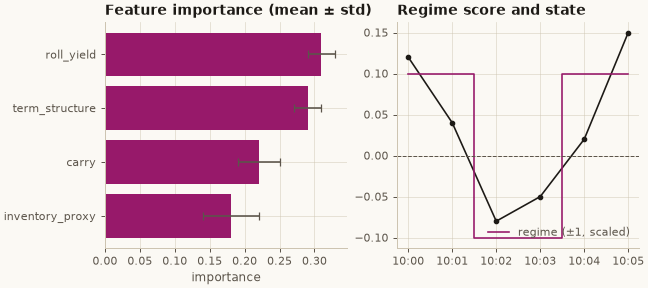

In [3]:
def draw(fig, c):
    left, right = fig.subplots(1, 2)
    left.barh(
        payload["x"][::-1],
        payload["y"][::-1],
        xerr=payload["error_y"][::-1],
        color=c["accent"],
        ecolor=c["muted"],
        capsize=3,
    )
    left.set_title("Feature importance (mean ± std)")
    left.set_xlabel(payload["y_label"])
    x = range(len(regime_payload["x"]))
    right.plot(x, regime_payload["score"], color=c["text"], marker="o", markersize=3.5)
    right.step(
        x,
        [0.1 * r for r in regime_payload["regime"]],
        where="mid",
        color=c["accent"],
        label="regime (±1, scaled)",
    )
    right.axhline(regime_payload["threshold"], color=c["muted"], linewidth=0.8, linestyle="--")
    right.set_xticks(list(x), [t[11:16] for t in regime_payload["x"]])
    right.set_title("Regime score and state")
    right.legend(loc="lower right")


nbfigures.figure(
    "nb03-feature-diagnostics",
    draw,
    alt="Feature importance bars with error bars, and a regime score with its thresholded state.",
)

## Reproducibility

In [4]:
import nbrepro

import polars as pl

inputs = pl.DataFrame({"feature": feature_names, "importance": importance, "std": std})
scores = pl.DataFrame({"ts": ts, "score": score})
nbrepro.footer(
    seed=None,
    data_hash=nbrepro.frame_hash(inputs),
    regime_data_hash=nbrepro.frame_hash(scores),
    data="hand-written illustrative inputs",
)

data hash:    sha256:ad8681a054ef3299fd7be9da261bf49cf50d3a21db4f2cf8bf0ba3973183c24e
seed:         none (nothing is random)
regime data hash: sha256:0948f096d4b6c317e4160904a4707f3dab0d6538e1ea9648de8358e951df9a3b
data:         hand-written illustrative inputs


git sha:      the commit containing this notebook (CI re-runs it there)
package:      pyopenquant built from that commit; dependencies from its uv.lock
